In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_path = "/content/drive/MyDrive/leaves/train"
test_path  = "/content/drive/MyDrive/leaves/test"

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:

DATASET_PATH = "/content/drive/MyDrive/leaves"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
NUM_CLASSES = train_data.num_classes
print("Number of classes:", NUM_CLASSES)
print("Classes:", train_data.class_indices)

Found 4274 images belonging to 12 classes.
Found 110 images belonging to 12 classes.
Number of classes: 12
Classes: {'Alstonia Scholaris': 0, 'Arjun': 1, 'Bael': 2, 'Basil': 3, 'Chinar': 4, 'Gauva': 5, 'Jamun': 6, 'Jatropha': 7, 'Lemon': 8, 'Mango': 9, 'Pomegranate': 10, 'Pongamia Pinnata': 11}


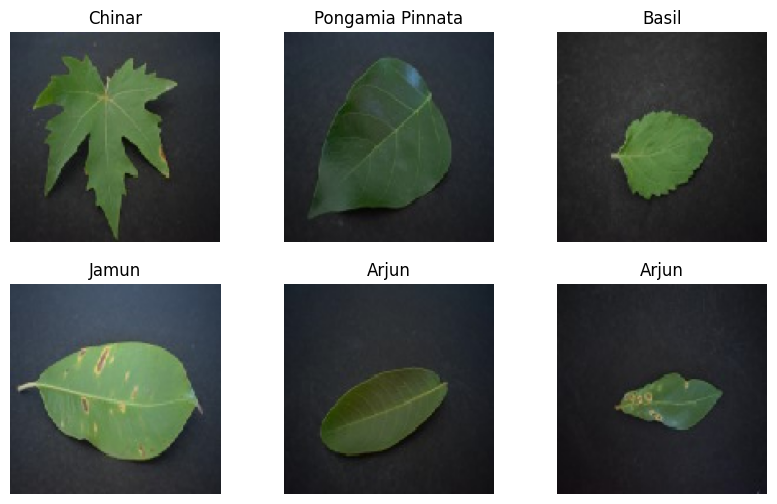

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,868 (28.21 MB)

 Trainable params: 7,393,868 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 790s 6s/step - accuracy: 0.3974 - loss: 1.7430 - val_accuracy: 0.5727 - val_loss: 1.3652
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 961ms/step - accuracy: 0.6438 - loss: 1.0650 - val_accuracy: 0.7182 - val_loss: 1.0223
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 957ms/step - accuracy: 0.7474 - loss: 0.7378 - val_accuracy: 0.7727 - val_loss: 0.9531
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 957ms/step - accuracy: 0.7984 - loss: 0.6024 - val_accuracy: 0.7818 - val_loss: 0.9953
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 127s 966ms/step - accuracy: 0.8264 - loss: 0.5004 - val_accuracy: 0.8091 - val_loss: 0.9710
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 124s 949ms/step - accuracy: 0.8588 - loss: 0.4170 - val_accuracy: 0.7364 - val_loss: 1.2824
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 143s 957ms/step - accuracy: 0.8566 - loss: 0.3988 - val_accuracy: 0.8091 - val_loss: 1.1004
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 124s 949ms/step - accuracy: 0.8992 - lo

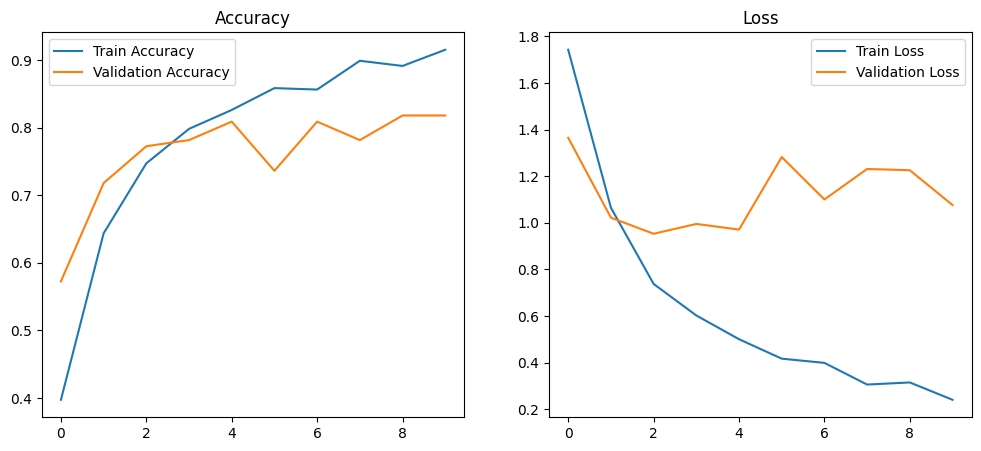

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.8182 - loss: 1.0765
Test Accuracy: 0.8181818127632141


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step


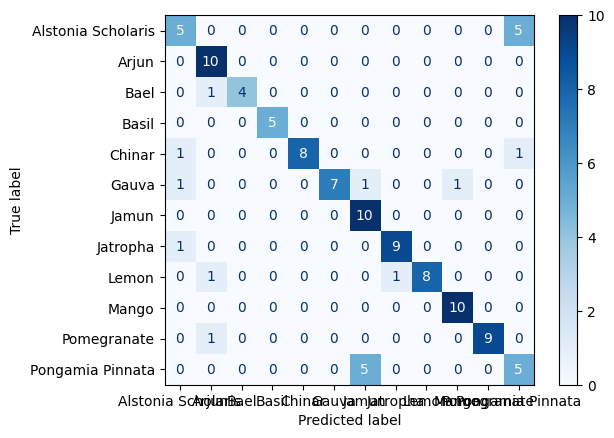

In [ ]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=test_data.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.show()